Cat image size (300, 451, 3)
Astronaut image size (512, 512, 3)
Coins image size (303, 384)


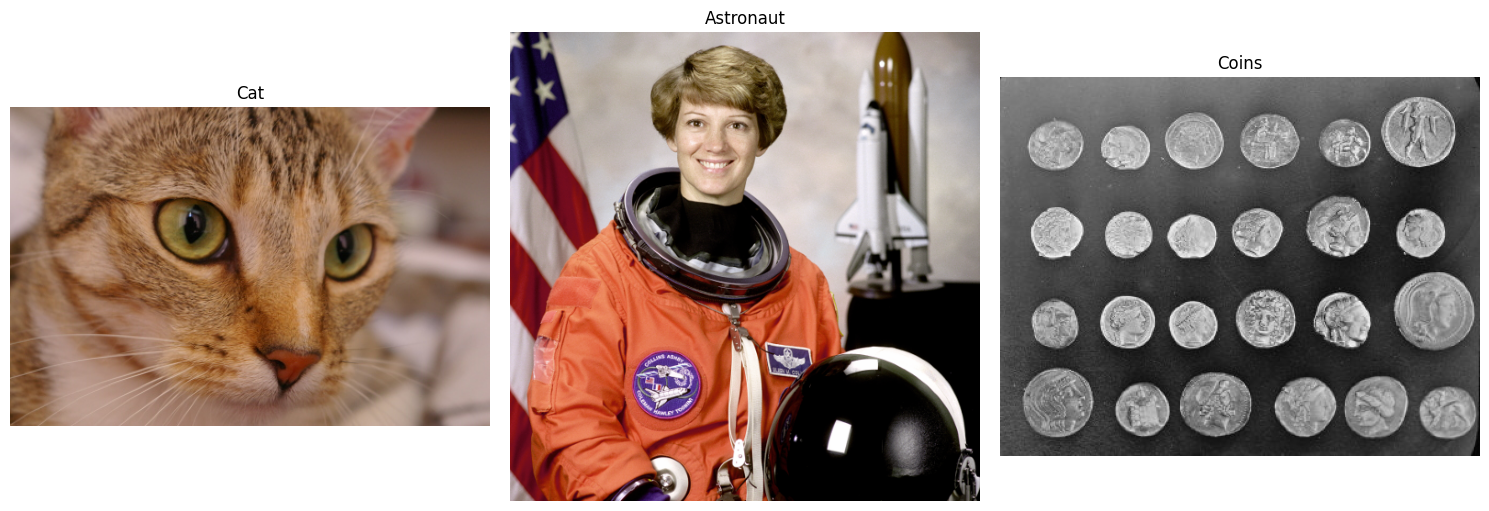

In [2]:
import cv2
from skimage import data
import matplotlib.pyplot as plt

# 1. Load the pre-loaded images from skimage
img_cat = data.cat() 
img_ast = data.astronaut()
img_coins = data.coins()

print("Cat image size",img_cat.shape)
print("Astronaut image size",img_ast.shape)
print("Coins image size",img_coins.shape)

# 2. Setup a grid to display all three results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display Cat (Color image)
axes[0].imshow(img_cat)
axes[0].set_title('Cat')
axes[0].axis('off')

# Display Astronaut (Color image)
axes[1].imshow(img_ast)
axes[1].set_title('Astronaut')
axes[1].axis('off')

# Display Coins (Grayscale image - needs gray colormap)
axes[2].imshow(img_coins, cmap='gray')
axes[2].set_title('Coins')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Converting to Grayscale image

| Property | RGB Image | Grayscale Image |
| :--- | :--- | :--- |
| **Channels** | 3 (Red, Green, Blue) | 1 (Intensity / Luminance) |
| **Data Size / Memory** | ~3x larger (typically 24 bits per pixel) | ~3x smaller (typically 8 bits per pixel) |
| **Pixel Value Structure** | Array of triplets: `[R, G, B]` (e.g., `[255, 0, 0]` for red) | Single scalar intensity value |
| **Pixel Value Range** | 0 to 255 for each channel (8-bit depth) | 0 (Black) to 255 (White) |
| **Array Dimensions** | 3D Array ($\text{Height} \times \text{Width} \times 3$) | 2D Array ($\text{Height} \times \text{Width}$) |

Cat image size (300, 451)
Astronaut image size (512, 512)
Coins image size (303, 384)


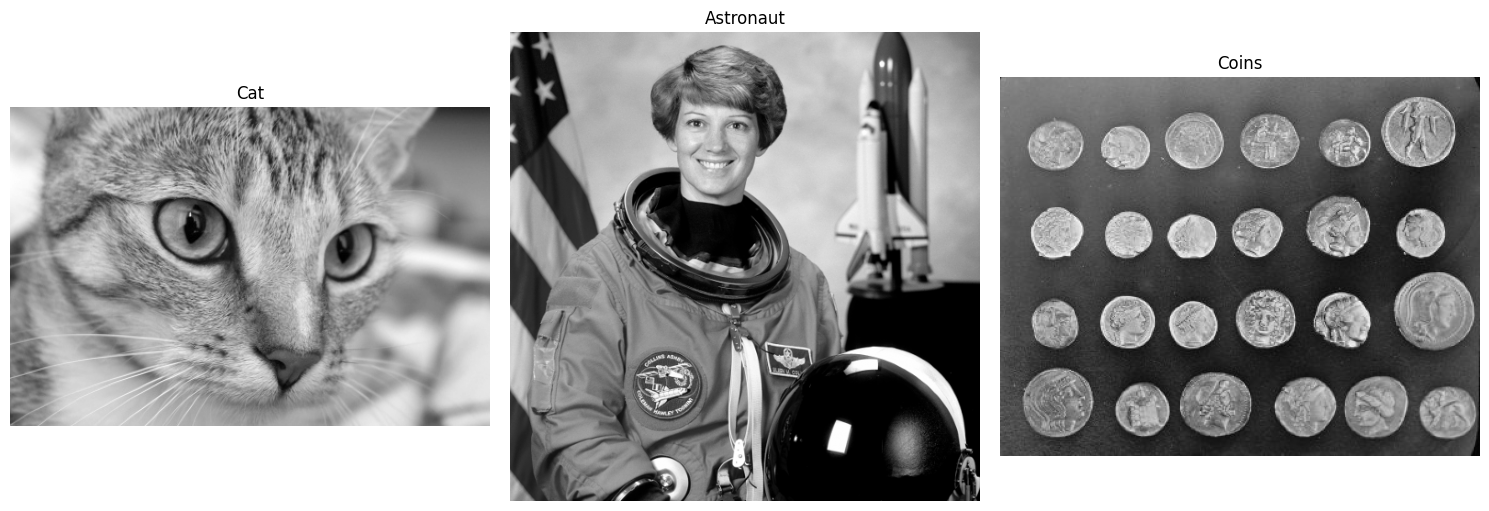

In [4]:
# Note: skimage loads in RGB. If you want to use OpenCV specific functions 
# that expect BGR, convert it:
img_cat_gray = cv2.cvtColor(img_cat, cv2.COLOR_RGB2GRAY)
img_ast_gray = cv2.cvtColor(img_ast, cv2.COLOR_RGB2GRAY)
img_coins_gray = img_coins


print("Cat image size",img_cat_gray.shape)
print("Astronaut image size",img_ast_gray.shape)
print("Coins image size",img_coins_gray.shape)

# 2. Setup a grid to display all three results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display Cat (Color image)
axes[0].imshow(img_cat_gray, cmap='gray')
axes[0].set_title('Cat')
axes[0].axis('off')

# Display Astronaut (Color image)
axes[1].imshow(img_ast_gray, cmap='gray')
axes[1].set_title('Astronaut')
axes[1].axis('off')

# Display Coins (Grayscale image - needs gray colormap)
axes[2].imshow(img_coins_gray, cmap='gray')
axes[2].set_title('Coins')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Pixel Processing

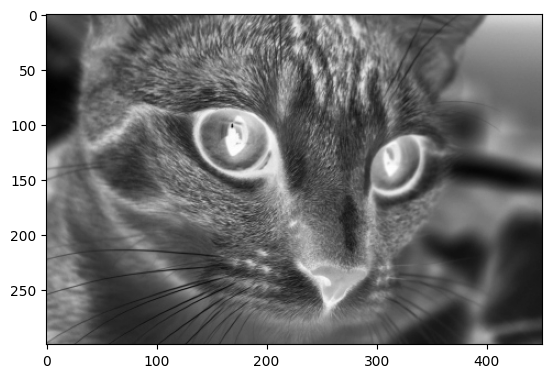

In [5]:
# negative image 
negative = 255 - img_cat_gray

plt.imshow(negative,cmap="gray")

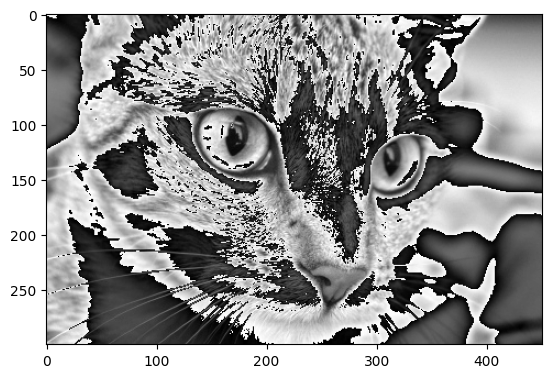

In [7]:
# Increasing Contrast 

Contrast = 2* img_cat_gray

plt.imshow(Contrast,cmap="gray")

- Note: Difference between Contrast and Brightness adjustments in image processing.
Contrast: Refers to the difference in luminance or color that makes an object distinguishable. Increasing contrast makes the dark areas darker and the bright areas brighter.
Brightness: Refers to the overall lightness or darkness of an image. Increasing brightness makes the entire image lighter, while decreasing it makes the image darker.

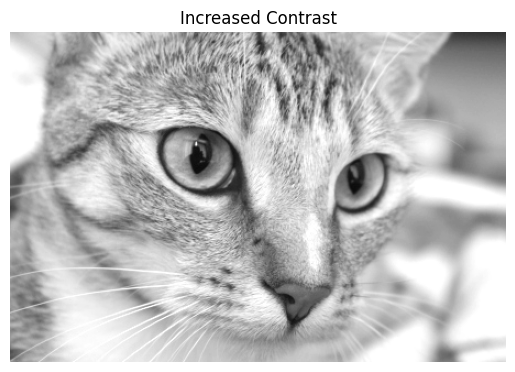

In [16]:
# Increase contrast and brightness of the grayscale cat image alpha > 1 increases contrast, beta adds brightness (positive value makes image brighter)
contrast = cv2.convertScaleAbs(img_cat_gray, alpha=1.5, beta=5)

plt.imshow(contrast, cmap="gray", vmin=0, vmax=255)
plt.title("Increased Contrast")
plt.axis("off")
plt.show()

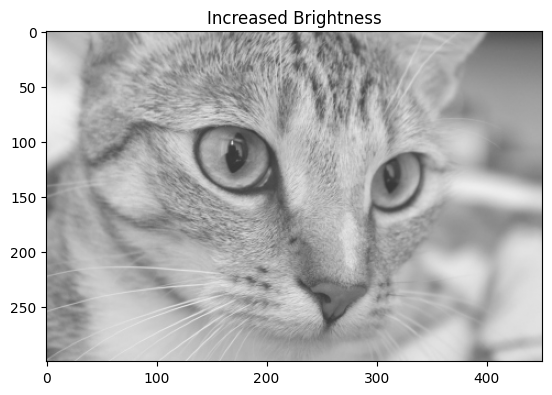

In [8]:
# Option 1: Using cv2.add (Recommended - automatically caps values at 255)
bright = cv2.add(img_cat_gray, 50)  # Increase brightness by 50 units

plt.imshow(bright, cmap="gray", vmin=0, vmax=255)
plt.title("Increased Brightness")
plt.show()

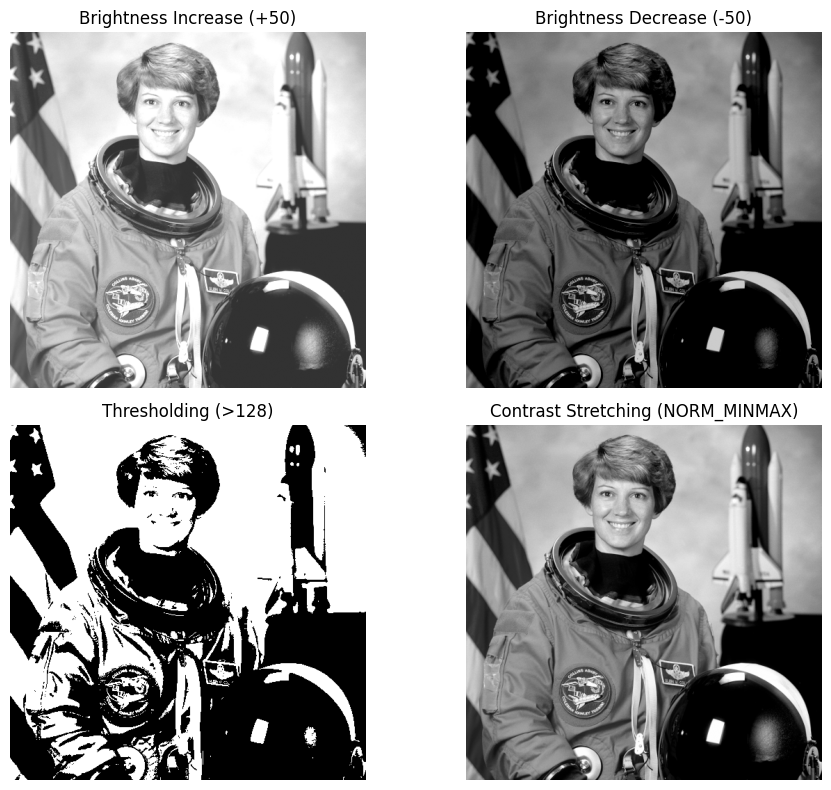

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = img_ast_gray

# 1. Brightness Increase
brightness = np.clip(img.astype(np.int16) + 50, 0, 255).astype(np.uint8)

# 2. Brightness Decrease
dark = np.clip(img.astype(np.int16) - 50, 0, 255).astype(np.uint8)

# 3. Thresholding
threshold = np.where(img > 128, 255, 0).astype(np.uint8) # if pixel value is greater than 128, set to 255 (white), else set to 0 (black)

# 4. Contrast Stretching
contrast = cv2.normalize(
    img,
    None,
    alpha=0,
    beta=255,
    norm_type=cv2.NORM_MINMAX
) # normalize the image to the full 0-255 range for contrast stretching 

# Plotting the results
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(brightness, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Brightness Increase (+50)')
axes[0, 0].axis('off')

axes[0, 1].imshow(dark, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Brightness Decrease (-50)')
axes[0, 1].axis('off')

axes[1, 0].imshow(threshold, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Thresholding (>128)')
axes[1, 0].axis('off')

axes[1, 1].imshow(contrast, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Contrast Stretching (NORM_MINMAX)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

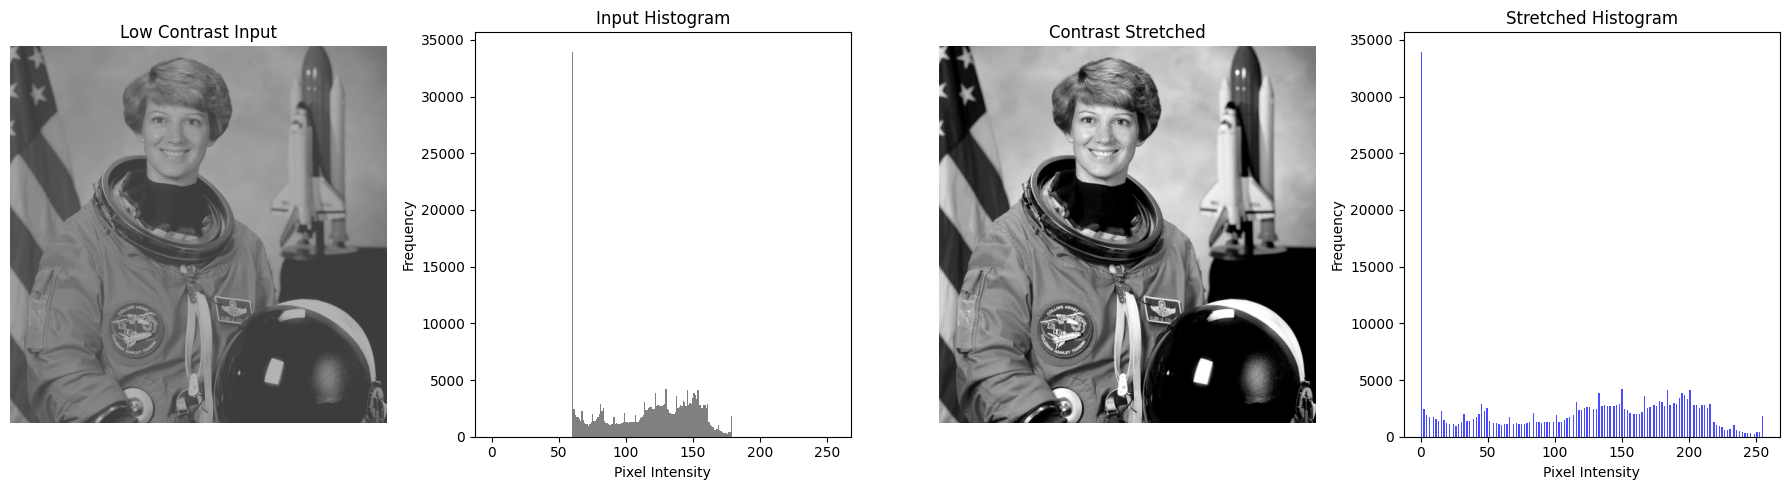

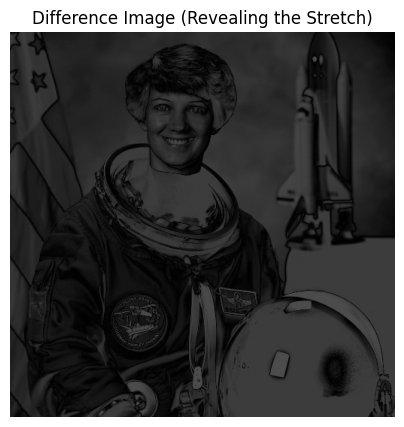

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- SIMULATION PREPARATION ---
# If your img_ast_gray is already full range, let's artificially compress it 
# to a narrow range (e.g., between 60 and 180) to simulate a low-contrast image.
img_ast_low_contrast = np.clip((img_ast_gray * 0.47) + 60, 0, 255).astype(np.uint8)
# ------------------------------

# Display the low-contrast image, its histogram, and the stretched version side-by-side
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# 1. Display the low-contrast image
axes[0].imshow(img_ast_low_contrast, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Low Contrast Input")
axes[0].axis("off")

# 2. Plot the original narrow intensity histogram
axes[1].hist(img_ast_low_contrast.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title("Input Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

# 3. Apply contrast stretching
img_ast_contrast = cv2.normalize(
    img_ast_low_contrast,
    None,
    alpha=0,
    beta=255,
    norm_type=cv2.NORM_MINMAX
)
axes[2].imshow(img_ast_contrast, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Contrast Stretched")
axes[2].axis("off")

# 4. Plot the stretched intensity histogram
axes[3].hist(img_ast_contrast.ravel(), bins=256, range=(0, 255), color='blue', alpha=0.7)
axes[3].set_title("Stretched Histogram")
axes[3].set_xlabel("Pixel Intensity")
axes[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Calculate and display the structural differences
diff_image = cv2.absdiff(img_ast_low_contrast, img_ast_contrast)
plt.figure(figsize=(5, 5))
plt.imshow(diff_image, cmap="gray", vmin=0, vmax=255)
plt.title("Difference Image (Revealing the Stretch)")
plt.axis("off")
plt.show()


In [37]:
print(img_ast_contrast - img_ast_low_contrast)


[[ 20 253 230 ...   5   2   4]
 [ 33  15   2 ...   4   2   2]
 [ 45  36  29 ...   5   3   2]
 ...
 [ 34  34  33 ... 196 196 196]
 [ 33  31  31 ... 196 196 196]
 [ 33  31  29 ... 196 196 196]]


## Linear Filter

#### a. Impulse Filter

Is the output exactly the same as the input? True


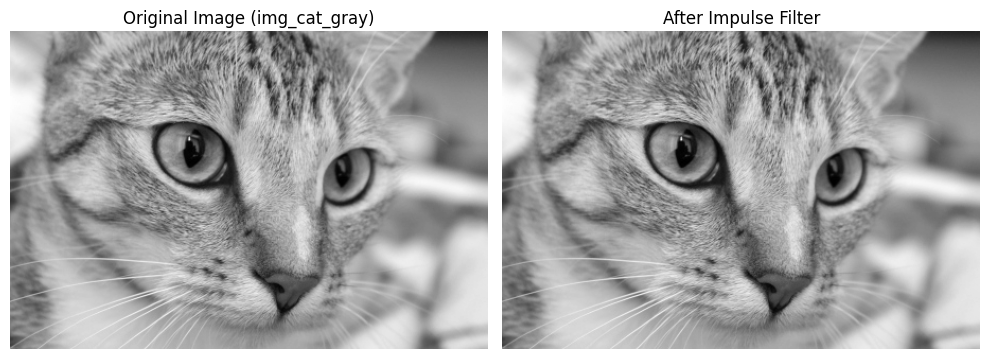

In [39]:
# Impulse Filter
# image * filter = same image 

# 1. Define a 3x3 Impulse (Identity) Kernel
# The center value must be 1, and all other elements must be 0.
kernel_impulse = np.array([[0, 0, 0],
                           [0, 1, 0],
                           [0, 0, 0]], dtype=np.float32)

# 2. Apply the filter using 2D convolution
# -1 ensures the output image has the same data depth as the input
img_filtered = cv2.filter2D(img_cat_gray, -1, kernel_impulse)

# 3. Verify mathematically that the images are 100% identical
are_identical = np.array_equal(img_cat_gray, img_filtered)
print(f"Is the output exactly the same as the input? {are_identical}")

# 4. Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_cat_gray, cmap="gray" if len(img_cat_gray.shape) == 2 else None)
axes[0].set_title("Original Image (img_cat_gray)")
axes[0].axis("off")

axes[1].imshow(img_filtered, cmap="gray" if len(img_filtered.shape) == 2 else None)
axes[1].set_title("After Impulse Filter")
axes[1].axis("off")

plt.tight_layout()
plt.show()


#### Image Shifting

Is the output exactly the same as the input? False


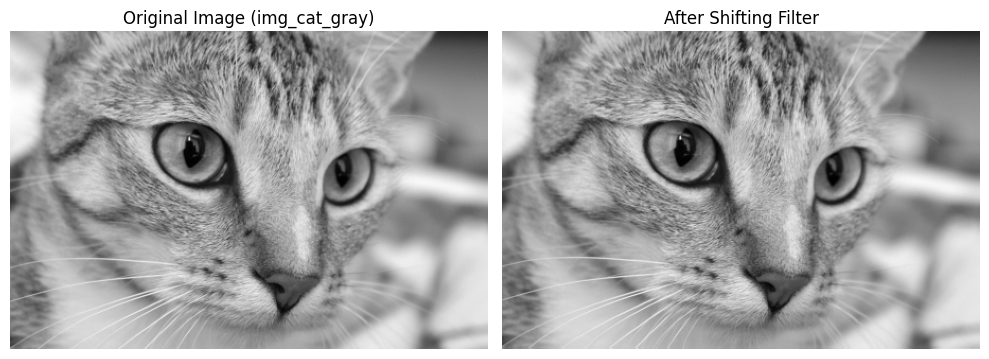

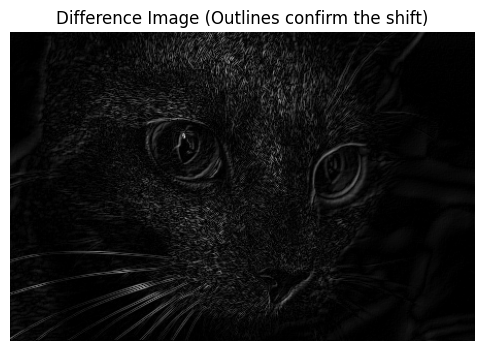

In [46]:
# shifting image filter

# 1. Define a 3x3 shifting kernel
# The bottom-right value must be 1, and all other elements must be 0.
kernel_impulse = np.array([[0, 0, 0],
                           [0, 0, 0],
                           [0, 0, 1]], dtype=np.float32)

# 2. Apply the filter using 2D convolution
# -1 ensures the output image has the same data depth as the input
img_filtered = cv2.filter2D(img_cat_gray, -1 , kernel_impulse)

# 3. Verify mathematically that the images are 100% identical
are_identical = np.array_equal(img_cat_gray, img_filtered)
print(f"Is the output exactly the same as the input? {are_identical}")

# 4. Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_cat_gray, cmap="gray" if len(img_cat_gray.shape) == 2 else None)
axes[0].set_title("Original Image (img_cat_gray)")
axes[0].axis("off")

axes[1].imshow(img_filtered, cmap="gray" if len(img_filtered.shape) == 2 else None)
axes[1].set_title("After Shifting Filter")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Calculate the absolute difference
diff_image = cv2.absdiff(img_cat_gray, img_filtered)

# Display the difference image
plt.figure(figsize=(6, 6))
plt.imshow(diff_image, cmap="gray")
plt.title("Difference Image (Outlines confirm the shift)")
plt.axis("off")
plt.show()


In [48]:
# Print a 3x3 window of pixels from the original image center
print("Original Pixels:\n", img_cat_gray[100:103, 100:103])

# Print the same window from the shifted image
print("\nShifted Pixels (Notice the values moved up and left):\n", img_filtered[100:103, 100:103])


Original Pixels:
 [[122 129 126]
 [123 125 129]
 [118 123 126]]

Shifted Pixels (Notice the values moved up and left):
 [[125 129 125]
 [123 126 122]
 [129 132 126]]


#### Average Filter

Is the output exactly the same as the input? False


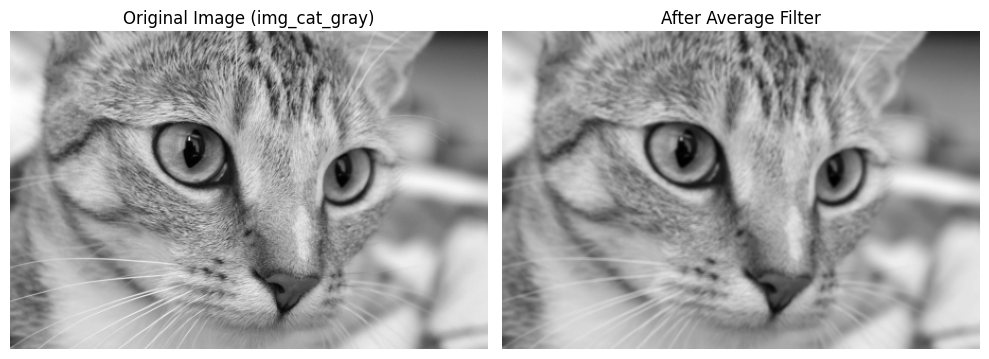

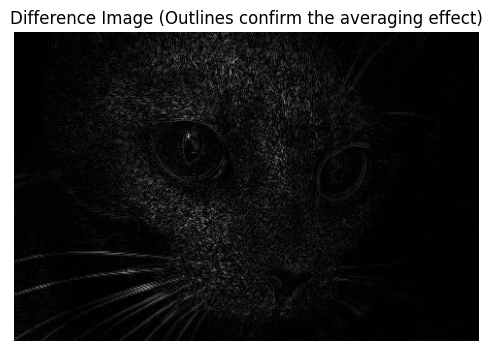

In [50]:
# Average image filter

# 1. Define a 3x3 average kernel
# All elements must be 1/9 to compute the average of the 3x3 neighborhood.
kernel_average = np.array([[1/9, 1/9, 1/9],
                           [1/9, 1/9, 1/9],
                           [1/9, 1/9, 1/9]], dtype=np.float32)

# 2. Apply the filter using 2D convolution
# -1 ensures the output image has the same data depth as the input
img_filtered = cv2.filter2D(img_cat_gray, -1 , kernel_average)

# 3. Verify mathematically that the images are 100% identical
are_identical = np.array_equal(img_cat_gray, img_filtered)
print(f"Is the output exactly the same as the input? {are_identical}")

# 4. Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_cat_gray, cmap="gray" if len(img_cat_gray.shape) == 2 else None)
axes[0].set_title("Original Image (img_cat_gray)")
axes[0].axis("off")

axes[1].imshow(img_filtered, cmap="gray" if len(img_filtered.shape) == 2 else None)
axes[1].set_title("After Average Filter")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Calculate the absolute difference
diff_image = cv2.absdiff(img_cat_gray, img_filtered)

# Display the difference image
plt.figure(figsize=(6, 6))
plt.imshow(diff_image, cmap="gray")
plt.title("Difference Image (Outlines confirm the averaging effect)")
plt.axis("off")
plt.show()


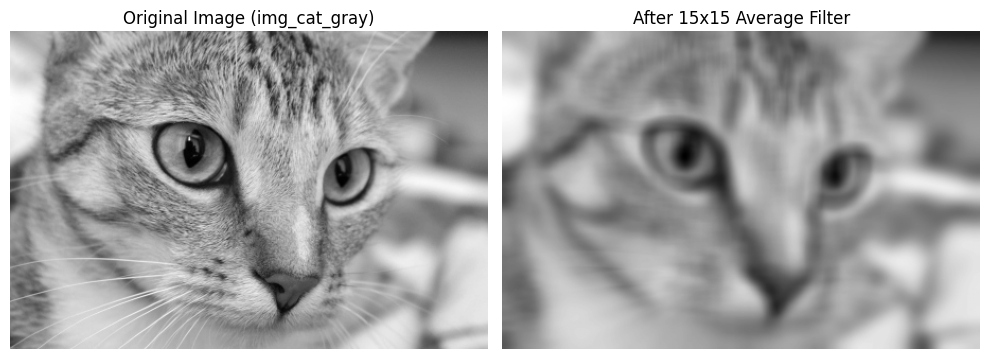

In [51]:
# Increasing the size of the averaging filter to 15x15
kernel_average_15 = np.ones((15, 15), dtype=np.float32) / (15 * 15)
img_filtered_15 = cv2.filter2D(img_cat_gray, -1, kernel_average_15)

# Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_cat_gray, cmap="gray" if len(img_cat_gray.shape) == 2 else None)
axes[0].set_title("Original Image (img_cat_gray)")
axes[0].axis("off")

axes[1].imshow(img_filtered_15, cmap="gray" if len(img_filtered_15.shape) == 2 else None)
axes[1].set_title("After 15x15 Average Filter")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Fuzzy Filter

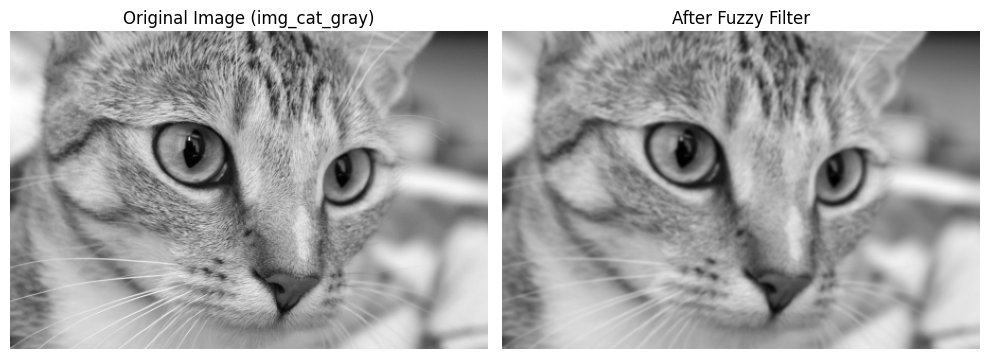

In [53]:
# Applying the Fuzzy Filter to the image kernel size 5*5
kernel_fuzzy = np.array([[0.00390625, 0.015625, 0.0234375, 0.015625, 0.00390625],
                         [0.015625,  0.0625,  0.09375,  0.0625,  0.015625],
                         [0.0234375, 0.09375, 0.140625, 0.09375, 0.0234375],
                         [0.015625,  0.0625,  0.09375,  0.0625,  0.015625],
                         [0.00390625, 0.015625, 0.0234375, 0.015625, 0.00390625]], dtype=np.float32)
img_filtered_fuzzy = cv2.filter2D(img_cat_gray, -1, kernel_fuzzy)

# Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_cat_gray, cmap="gray" if len(img_cat_gray.shape) == 2 else None)
axes[0].set_title("Original Image (img_cat_gray)")
axes[0].axis("off")

axes[1].imshow(img_filtered_fuzzy, cmap="gray" if len(img_filtered_fuzzy.shape) == 2 else None)
axes[1].set_title("After Fuzzy Filter")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### Gaussian Filter

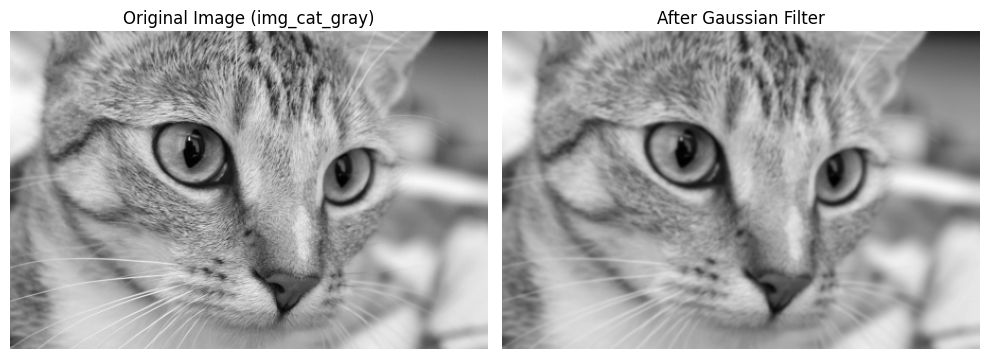

In [54]:
# Applying the Gaussian Filter to the image kernel size 5*5
kernel_gaussian = cv2.getGaussianKernel(5, 1)
kernel_gaussian = kernel_gaussian @ kernel_gaussian.T
img_filtered_gaussian = cv2.filter2D(img_cat_gray, -1, kernel_gaussian)

# Display the results side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_cat_gray, cmap="gray" if len(img_cat_gray.shape) == 2 else None)
axes[0].set_title("Original Image (img_cat_gray)")
axes[0].axis("off")

axes[1].imshow(img_filtered_gaussian, cmap="gray" if len(img_filtered_gaussian.shape) == 2 else None)
axes[1].set_title("After Gaussian Filter")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Non Linear Filter

## Template Matching

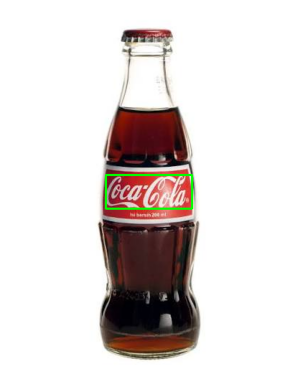

In [61]:
import cv2
import numpy as np

# 1. Load images in grayscale for faster processing
img = cv2.imread('C:\\Users\\debas\\Desktop\\Computer-Vision-Resource\\dataset\\source.jpg', cv2.IMREAD_GRAYSCALE)
template = cv2.imread('C:\\Users\\debas\\Desktop\\Computer-Vision-Resource\\dataset\\template.jpg', cv2.IMREAD_GRAYSCALE)
w, h = template.shape[::-1]

# 2. Apply template matching using a normalized method
res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)

# 3. Localize the best match
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

# 4. Determine coordinates (TM_CCOEFF_NORMED looks for maximum value)
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

# 5. Draw bounding box on original image using matplotlib
img_color = cv2.imread('C:\\Users\\debas\\Desktop\\Computer-Vision-Resource\\dataset\\source.jpg')
cv2.rectangle(img_color, top_left, bottom_right, (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()  


## Image Processing In Frequency Domain 

## Deconvolutions

## Sampling Theory and Aliasing